# ANN Wind U/V Forecasting

Uses `wind_uv.csv` (U and V wind components in kt) to train a **feedforward ANN** for time-series forecasting.
Compare with RNN and LSTM on the same data.

**ANN**: Treats the past 24 steps as a flat input vector (48 features) and predicts the next U, V. No recurrence.

In [9]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3050


In [10]:
# Load wind U/V data (same as LSTM/RNN notebooks)
csv_path = Path("wind_uv.csv")
df = pd.read_csv(csv_path)

date_col = df.columns[0]
df["datetime"] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=["datetime"])

u_col = [c for c in df.columns if "U" in c and "kt" in c][0]
v_col = [c for c in df.columns if "V" in c and "kt" in c][0]
df["U"] = pd.to_numeric(df[u_col], errors="coerce")
df["V"] = pd.to_numeric(df[v_col], errors="coerce")
df = df.dropna(subset=["U", "V"])

uv = df[["U", "V"]].values.astype(np.float32)
print(f"Loaded {len(uv)} rows. U range: [{uv[:, 0].min():.2f}, {uv[:, 0].max():.2f}], V range: [{uv[:, 1].min():.2f}, {uv[:, 1].max():.2f}]")

Loaded 11576 rows. U range: [-15.21, 14.85], V range: [-27.58, 16.64]


In [ ]:
# Normalize U, V (zero mean, unit variance)
u_mean, u_std = uv[:, 0].mean(), uv[:, 0].std()
v_mean, v_std = uv[:, 1].mean(), uv[:, 1].std()
uv_norm = np.column_stack([
    (uv[:, 0] - u_mean) / (u_std + 1e-8),
    (uv[:, 1] - v_mean) / (v_std + 1e-8),
])

# Create sequences: (seq_len, 2) -> predict next (2,)
seq_len = 24
X, y = [], []
for i in range(len(uv_norm) - seq_len):
    X.append(uv_norm[i : i + seq_len].flatten())  # Flatten for ANN: (24*2,) = 48
    y.append(uv_norm[i + seq_len])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
print(f"Sequences: X {X.shape}, y {y.shape} (ANN uses flattened input)")

Sequences: X (11526, 100), y (11526, 2) (ANN uses flattened input)


In [12]:
# Train/test split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

Train: 9220, Test: 2306


In [13]:
class ANNWind(torch.nn.Module):
    """Feedforward ANN: flat input (seq_len*2) -> hidden -> output (2)"""
    def __init__(self, input_size=48, hidden_size=64, dropout=0.2):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
        self.fc3 = torch.nn.Linear(hidden_size, 2)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

model = ANNWind().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
print(model)

ANNWind(
  (fc1): Linear(in_features=48, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [14]:
epochs = 50
model.train()
for ep in range(epochs):
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (ep + 1) % 10 == 0 or ep == 0:
        print(f"Epoch {ep + 1}/{epochs}  loss: {total_loss / len(train_loader):.6f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x100 and 48x64)

In [ ]:
model.eval()
preds, tgts = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        p = model(xb).cpu().numpy()
        preds.append(p)
        tgts.append(yb.numpy())

preds = np.vstack(preds)
tgts = np.vstack(tgts)

preds_denorm = np.column_stack([preds[:, 0] * u_std + u_mean, preds[:, 1] * v_std + v_mean])
tgts_denorm = np.column_stack([tgts[:, 0] * u_std + u_mean, tgts[:, 1] * v_std + v_mean])

rmse_u = np.sqrt(np.mean((preds_denorm[:, 0] - tgts_denorm[:, 0]) ** 2))
rmse_v = np.sqrt(np.mean((preds_denorm[:, 1] - tgts_denorm[:, 1]) ** 2))
rmse_overall = np.sqrt(np.mean((preds_denorm - tgts_denorm) ** 2))
print("RMSE (kt):")
print(f"  U: {rmse_u:.4f}  V: {rmse_v:.4f}  Overall: {rmse_overall:.4f}")
corr_u = np.corrcoef(preds_denorm[:, 0], tgts_denorm[:, 0])[0, 1]
corr_v = np.corrcoef(preds_denorm[:, 1], tgts_denorm[:, 1])[0, 1]
print("Correlation (pred vs actual):")
print(f"  U: {corr_u:.4f}  V: {corr_v:.4f}")

RMSE (kt):
  U: 1.8566  V: 2.0251  Overall: 1.9427
Correlation (pred vs actual):
  U: 0.9209  V: 0.9642


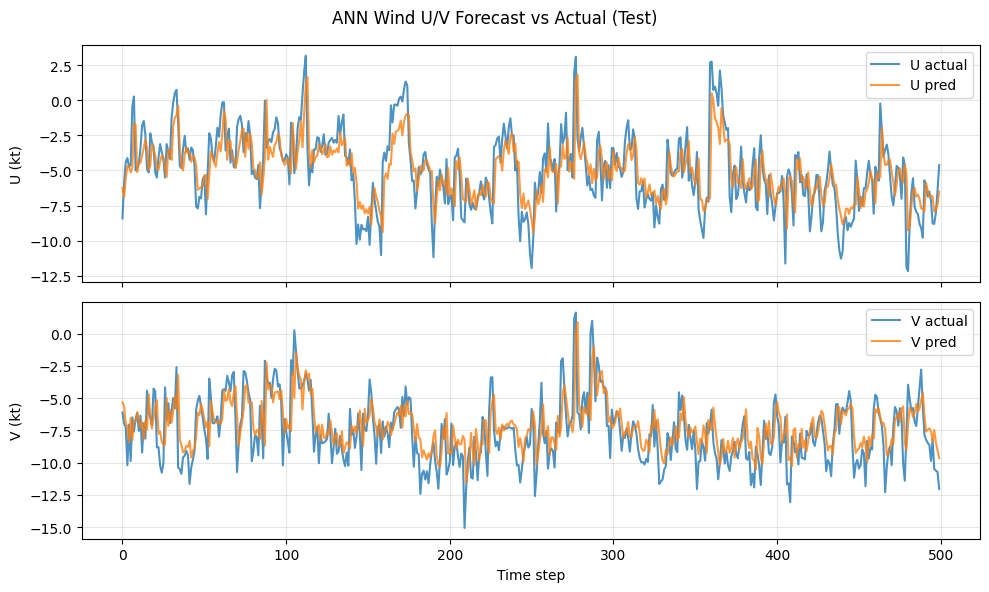

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
n_plot = min(500, len(preds))
ax[0].plot(tgts_denorm[:n_plot, 0], label="U actual", alpha=0.8)
ax[0].plot(preds_denorm[:n_plot, 0], label="U pred", alpha=0.8)
ax[0].set_ylabel("U (kt)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[1].plot(tgts_denorm[:n_plot, 1], label="V actual", alpha=0.8)
ax[1].plot(preds_denorm[:n_plot, 1], label="V pred", alpha=0.8)
ax[1].set_ylabel("V (kt)")
ax[1].set_xlabel("Time step")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.suptitle("ANN Wind U/V Forecast vs Actual (Test)")
plt.tight_layout()
plt.show()